In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device being used: {device}")

Device being used: cuda


In [3]:
path_data="/kaggle/input/datasets/nachmanrog/comb-ts-size/comb.npy"
f_tot=np.load(path_data)
rng = np.random.default_rng(seed=42)
rng.shuffle(f_tot)

f_tot = torch.tensor(f_tot)
f_tot = torch.log1p(f_tot)  # log(1 + x), handles zeros safely
f_tot = f_tot / f_tot.max()  # or min-max after log
f_tot = f_tot.unsqueeze(1)
print(f_tot.shape)

torch.Size([32325, 1, 214, 214])


In [4]:
from torch.utils.data import random_split, TensorDataset

# 2. Define your split proportions (e.g., 70% Train, 15% Val, 15% Test)
train_size = int(0.9 * len(f_tot))
val_size = int(0.05 * len(f_tot))
test_size = int( len(f_tot))-train_size-val_size


# 3. Perform the split (Optional: pass a Generator for reproducibility)
generator = torch.Generator().manual_seed(42)
train_set,val_set, test_set = random_split(
    f_tot,
    [train_size,val_size,  test_size],
    generator=generator
)

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


train_loader = DataLoader(
    train_set,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_set,
    batch_size=128,
    shuffle=False
)

In [6]:
class Autoencoder4(nn.Module):
    def __init__(self):
        super(Autoencoder4, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 10, 5, stride=2, padding=1),
            #nn.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            
            nn.Conv2d(10, 10, 5, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.Dropout2d(0.25),
            nn.Conv2d(10, 20, 5, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            
            nn.Conv2d(20, 20, 5, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.Dropout2d(0.25),
            nn.Flatten(),
            nn.LazyLinear(2000),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.25),
            nn.LazyLinear(500),
            
        )
        self.decoder = nn.Sequential(
            nn.Linear(500, 2000),
            nn.LeakyReLU(0.01),
            nn.Linear(2000, 20 * 13 * 13),
            #nn.BatchNorm1d(20 * 13 * 13),
            nn.LeakyReLU(0.01),
            nn.Unflatten(1, (20, 13, 13)),               # -> 20 x 13 x 13
            nn.Upsample(size=27, mode='bilinear', align_corners=False),        # 13 -> 27
            nn.Conv2d(20, 10, 3, stride=1, padding=1),
            #nn.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            nn.Upsample(size=53, mode='bilinear', align_corners=False),        # 27 -> 53
            nn.Conv2d(10, 10, 3, stride=1, padding=1),
            #nn.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            nn.Upsample(size=107, mode='bilinear', align_corners=False),       # 53 -> 107
            nn.Conv2d(10, 10, 3, stride=1, padding=1),
            #n.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            nn.Upsample(size=214, mode='bilinear', align_corners=False),       # 107 -> 214
            nn.Conv2d(10, 1, 3, stride=1, padding=1),
            #nn.BatchNorm2d(1),
            nn.Hardtanh(min_val=0.0, max_val=1.0)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    def encode(self, x):
        return self.encoder(x)

In [7]:
class gzLoss2(nn.Module):
    def __init__(self):
        super(gzLoss2, self).__init__()

    def forward(self, pred, target):
        sig_mask = target > 0
        bg_mask = ~sig_mask

        bg_loss = (pred[bg_mask] - target[bg_mask]).abs().mean() if bg_mask.any() else pred.new_tensor(0.0)
        sig_loss = (pred[sig_mask] - target[sig_mask]).abs().mean() if sig_mask.any() else pred.new_tensor(0.0)
        #print(f"bg_loss={bg_loss.item():.5f}  sig_loss={sig_loss.item():.5f}  frac_signal={sig_mask.float().mean().item():.6f}")
        return 0.5 * bg_loss + 0.5 * sig_loss

In [17]:
model = Autoencoder4().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = gzLoss2()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want val_loss to go DOWN
    factor=0.5,        # multiply LR by this when triggered (e.g. 1e-3 -> 5e-4)
    patience=3,         # wait this many epochs of no improvement before reducing
    threshold=1e-4,     # minimum change to count as "improvement"
)

In [9]:
device = next(model.parameters()).device  # find out where the model currently lives
dummy_input = torch.zeros(1, 1, 214, 214, device=device)

with torch.no_grad():
    model(dummy_input)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")


Total parameters: 14,549,411
Trainable parameters: 14,549,411


In [10]:
print(model)

Autoencoder4(
  (encoder): Sequential(
    (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(10, 10, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(10, 20, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (6): LeakyReLU(negative_slope=0.01)
    (7): Conv2d(20, 20, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (8): LeakyReLU(negative_slope=0.01)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=2880, out_features=2000, bias=True)
    (12): LeakyReLU(negative_slope=0.01)
    (13): Dropout(p=0.25, inplace=False)
    (14): Linear(in_features=2000, out_features=500, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=500, out_features=2000, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=2000

In [18]:
from datetime import datetime
local_time = datetime.now()
saving_path="/kaggle/working/"+local_time.strftime("%Y%m%d_%H%M%S")
os.mkdir(saving_path)
num_epochs = 20
best_val_loss = float('inf')
patience = 4
patience_counter = 0
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images in train_loader:
        images = images.to(device).float()

        outputs = model(images)
        loss = criterion(outputs, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images in val_loader:
            images = images.to(device).float()
            outputs= model(images)
            loss = criterion(outputs, images)
            #print("val",loss)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(),  os.path.join(saving_path,'best_model.pt'))  # save best version
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss
    }
    torch.save(checkpoint, os.path.join(saving_path,'latest_checkpoint.pt'))
    if (epoch + 1) % 1== 0:
      print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.8f}, Val Loss: {val_loss:.8f}")
      torch.save(model.state_dict(), os.path.join(saving_path,f'model_epoch_{epoch+1}.pt'))


Epoch [1/20], Loss: 0.03761209, Val Loss: 0.03508776
Epoch [2/20], Loss: 0.03240927, Val Loss: 0.03146493
Epoch [3/20], Loss: 0.02880328, Val Loss: 0.02524597
Epoch [4/20], Loss: 0.02338116, Val Loss: 0.02138679
Epoch [5/20], Loss: 0.02054606, Val Loss: 0.01953595
Epoch [6/20], Loss: 0.01894588, Val Loss: 0.01886517
Epoch [7/20], Loss: 0.01760752, Val Loss: 0.01694898
Epoch [8/20], Loss: 0.01671355, Val Loss: 0.01619482
Epoch [9/20], Loss: 0.01603834, Val Loss: 0.01549646
Epoch [10/20], Loss: 0.01545349, Val Loss: 0.01579873
Epoch [11/20], Loss: 0.01497733, Val Loss: 0.01532118
Epoch [12/20], Loss: 0.01466494, Val Loss: 0.01511726
Epoch [13/20], Loss: 0.01450855, Val Loss: 0.01429334
Epoch [14/20], Loss: 0.01400989, Val Loss: 0.01433831
Epoch [15/20], Loss: 0.01391546, Val Loss: 0.01454736
Epoch [16/20], Loss: 0.01347681, Val Loss: 0.01338642
Epoch [17/20], Loss: 0.01315591, Val Loss: 0.01310450
Epoch [18/20], Loss: 0.01295416, Val Loss: 0.01322244
Epoch [19/20], Loss: 0.01268963, Val 

In [19]:
'''
model.load_state_dict(torch.load('/kaggle/input/models/nachmanrog/auto4/pytorch/default/1/best_model_aoutoencoder4.pt', weights_only=True))
model.to(device)
'''

"model.load_state_dict(torch.load('/kaggle/input/models/nachmanrog/auto4/pytorch/default/1/best_model_aoutoencoder4.pt', weights_only=True))\n\nmodel.to(device)"

In [20]:
torch.save(model.state_dict(), os.path.join(saving_path,'conv_autoencoder_dict.pth'))
torch.save(model, os.path.join(saving_path,'conv_autoencoder.pth'))

rwcom torch.Size([128, 1, 214, 214])


<Figure size 6912x5184 with 0 Axes>

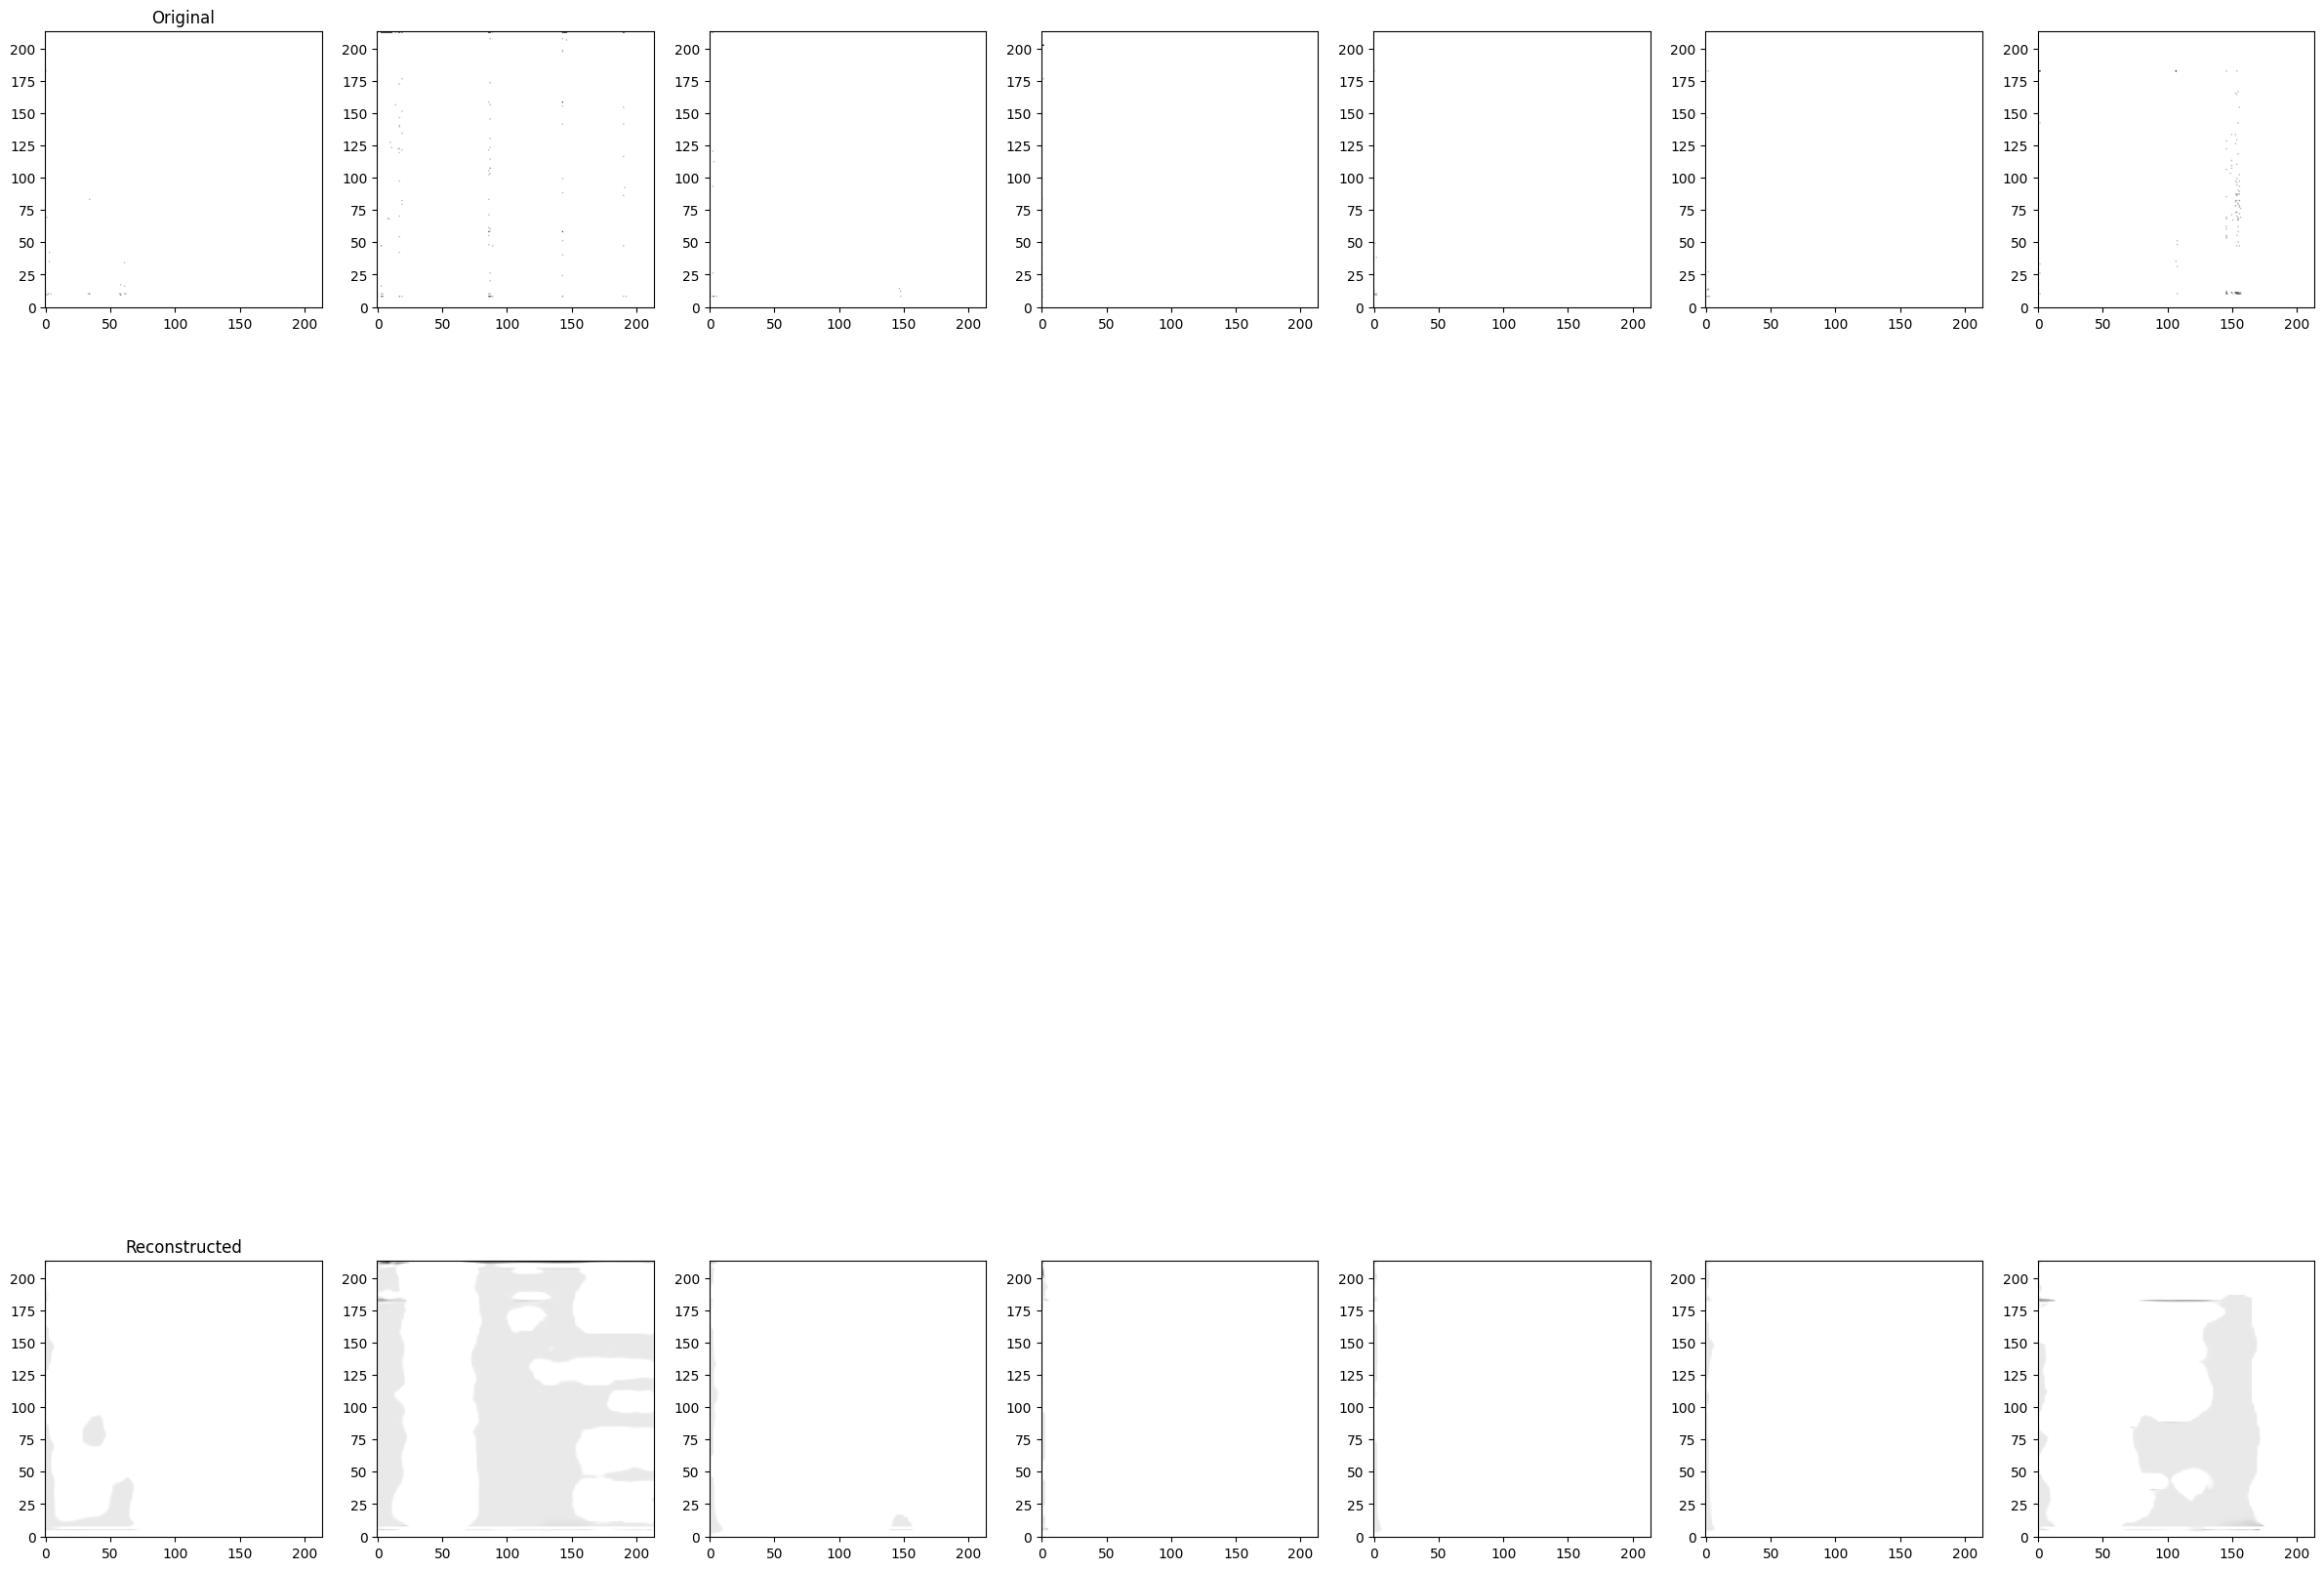

In [21]:


model.eval()
with torch.no_grad():
    for data in test_loader:
        data = data.to(device).float()
        recon = model(data)

        print("rwcom",recon.shape)
        break

plt.figure(dpi=1080)
fig, ax = plt.subplots(2, 7, figsize=(30, 30))
for i in range(7):
    x=100
    orig_hist = data[i+x, 0].cpu().numpy()
    recon_hist = recon[i+x, 0].cpu().numpy()
    im0 = ax[0, i].imshow(orig_hist, origin='lower',vmax=0.3, cmap='gray_r')
    im1 = ax[1, i].imshow(recon_hist, origin='lower',vmax=1, cmap='gray_r')
ax[0, 0].set_title('Original')
ax[1, 0].set_title('Reconstructed')
plt.show()

In [22]:
local_time.strftime("%Y%m%d_%H%M%S")

'20260825_091953'